# Prerequesites

In [105]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

RANDOM_VALUE = 53
np.random.seed(RANDOM_VALUE)

In [64]:
df = pd.read_csv('/home/ibrahim/jupyter/datasets/housePrice.csv')
df.head(10)

,Area,Room,Parking,Warehouse,Elevator,Address,Price,Price(USD)
0,63,1,True,True,True,Shahran,1.850000e+09,61666.67
1,60,1,True,True,True,Shahran,1.850000e+09,61666.67
2,79,2,True,True,True,Pardis,5.500000e+08,18333.33
3,95,2,True,True,True,Shahrake Qods,9.025000e+08,30083.33
4,123,2,True,True,True,Shahrake Gharb,7.000000e+09,233333.33
5,70,2,True,True,False,North Program Organization,2.050000e+09,68333.33
6,87,2,True,True,True,Pardis,6.000000e+08,20000.00
7,59,1,True,True,True,Shahran,2.150000e+09,71666.67
8,54,2,True,True,False,Andisheh,4.930000e+08,16433.33
9,71,1,True,True,True,West Ferdows Boulevard,2.370000e+09,79000.00


# Data Assessing and Cleaning

In [65]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3479 entries, 0 to 3478
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Area        3479 non-null   object 
 1   Room        3479 non-null   int64  
 2   Parking     3479 non-null   bool   
 3   Warehouse   3479 non-null   bool   
 4   Elevator    3479 non-null   bool   
 5   Address     3456 non-null   object 
 6   Price       3479 non-null   float64
 7   Price(USD)  3479 non-null   float64
dtypes: bool(3), float64(2), int64(1), object(2)
memory usage: 146.2+ KB


In [66]:
# df['Area'] = df['Area'].astype(int)

In [67]:
df['Area'].value_counts().sort_index(ascending=True).head(10)

Area
 1,000                1
 16,160,000,000       1
 2,550,000,000        1
 3,310,000,000        1
 3,600                1
 8,400,000,000        1
100                 104
101                  21
102                  16
103                  17
Name: count, dtype: int64

In [68]:
df['Area'] = df['Area'].str.replace(',', '')
df['Area'] = df['Area'].astype(int)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3479 entries, 0 to 3478
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Area        3479 non-null   int64  
 1   Room        3479 non-null   int64  
 2   Parking     3479 non-null   bool   
 3   Warehouse   3479 non-null   bool   
 4   Elevator    3479 non-null   bool   
 5   Address     3456 non-null   object 
 6   Price       3479 non-null   float64
 7   Price(USD)  3479 non-null   float64
dtypes: bool(3), float64(2), int64(2), object(1)
memory usage: 146.2+ KB


In [69]:
df['Price(USD)'] = df['Price(USD)'].astype(int)
df['Price'] = df['Price'].astype(int)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3479 entries, 0 to 3478
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Area        3479 non-null   int64 
 1   Room        3479 non-null   int64 
 2   Parking     3479 non-null   bool  
 3   Warehouse   3479 non-null   bool  
 4   Elevator    3479 non-null   bool  
 5   Address     3456 non-null   object
 6   Price       3479 non-null   int64 
 7   Price(USD)  3479 non-null   int64 
dtypes: bool(3), int64(4), object(1)
memory usage: 146.2+ KB


In [70]:
df.isna().sum()

Area           0
Room           0
Parking        0
Warehouse      0
Elevator       0
Address       23
Price          0
Price(USD)     0
dtype: int64

In [71]:
df.shape

(3479, 8)

## Removing Outliers

Standard Deviation of Area: 316726628.81651556
Standard Deviation of Room: 0.7582753293813761
Standard Deviation of Price: 8099934524.333206
Standard Deviation of Price(USD): 269997.8307725223


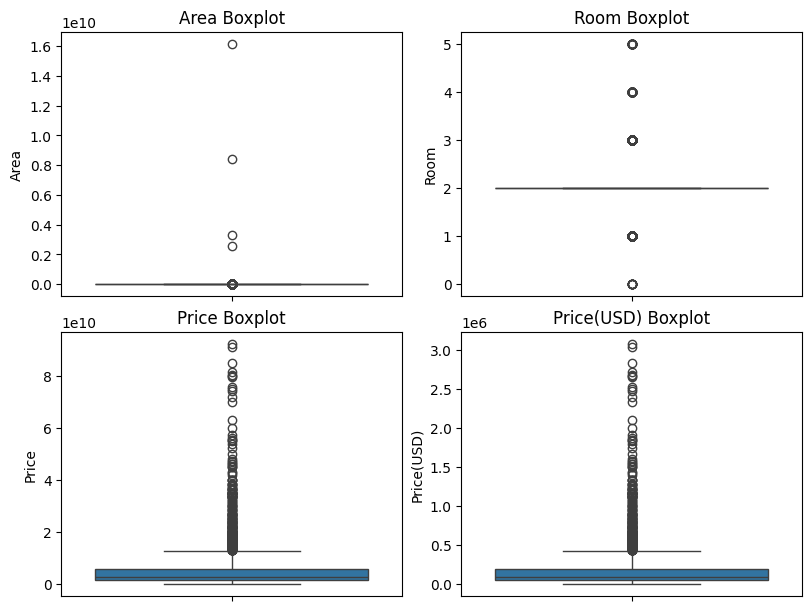

In [72]:
df_numeric = df.select_dtypes('number')
df_numeric_cols = df_numeric.columns
df_numeric_cols

fig, axes = plt.subplots(2, 2, constrained_layout=True, figsize=(8,6))
axes = axes.flatten()

for i, col in enumerate(df_numeric_cols):
    sns.boxplot(df[col], ax=axes[i])
    axes[i].set_title(f'{col} Boxplot')
    print(f'Standard Deviation of {col}: {df[col].std()}')

In [73]:
df['Area'].value_counts().sort_index(ascending=False).head(10)

Area
16160000000    1
8400000000     1
3310000000     1
2550000000     1
3600           1
1000           1
929            1
900            1
863            1
750            2
Name: count, dtype: int64

In [74]:
Q1 = df['Area'].quantile(0.25)
Q3 = df['Area'].quantile(0.75)
IQR = Q3 - Q1
print(f'IQR value: {IQR}')

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df = df[(df['Area'] >= lower_bound) & (df['Area'] <= upper_bound)]

IQR value: 51.0


In [75]:
Q1 = df['Price'].quantile(0.25)
Q3 = df['Price'].quantile(0.75)
IQR = Q3 - Q1
print(f'IQR value: {IQR}')

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df = df[(df['Price'] >= lower_bound) & (df['Price'] <= upper_bound)]

IQR value: 3750000000.0


In [76]:
Q1 = df['Price(USD)'].quantile(0.25)
Q3 = df['Price(USD)'].quantile(0.75)
IQR = Q3 - Q1
print(f'IQR value: {IQR}')

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df = df[(df['Price(USD)'] >= lower_bound) & (df['Price(USD)'] <= upper_bound)]

IQR value: 100000.0


Standard Deviation of Area: 27.037455158944063
Standard Deviation of Room: 0.608682573255878
Standard Deviation of Price: 2080155341.7331154
Standard Deviation of Price(USD): 69338.51964222032


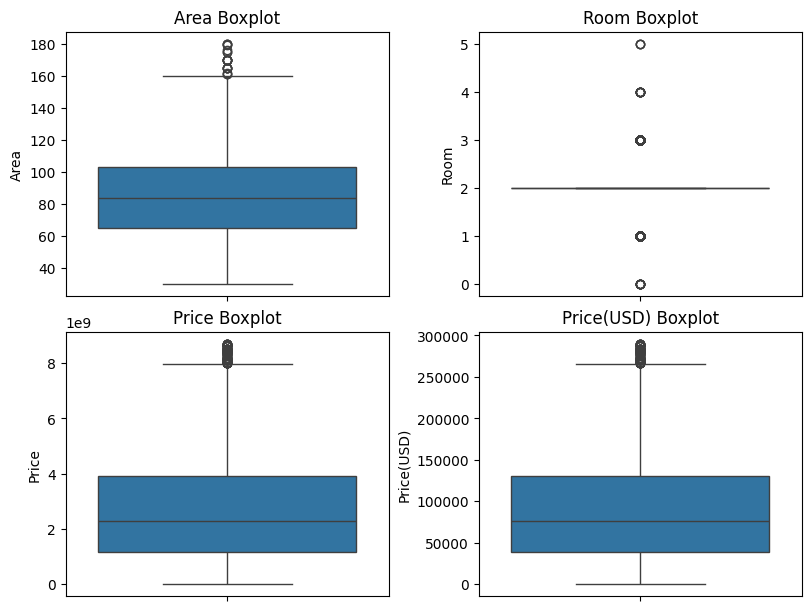

In [77]:
df_numeric = df.select_dtypes('number')
df_numeric_cols = df_numeric.columns
df_numeric_cols

fig, axes = plt.subplots(2, 2, constrained_layout=True, figsize=(8,6))
axes = axes.flatten()

for i, col in enumerate(df_numeric_cols):
    sns.boxplot(df[col], ax=axes[i])
    axes[i].set_title(f'{col} Boxplot')
    print(f'Standard Deviation of {col}: {df[col].std()}')

# Exploratory Analysis

In [78]:
df.describe(include='all')

,Area,Room,Parking,Warehouse,Elevator,Address,Price,Price(USD)
count,2885.000000,2885.000000,2885,2885,2885,2862,2.885000e+03,2885.000000
unique,NaN,NaN,2,2,2,187,NaN,NaN
top,NaN,NaN,True,True,True,Punak,NaN,NaN
freq,NaN,NaN,2376,2613,2227,155,NaN,NaN
mean,86.112998,1.889081,NaN,NaN,NaN,NaN,2.834685e+09,94489.164991
std,27.037455,0.608683,NaN,NaN,NaN,NaN,2.080155e+09,69338.519642
min,30.000000,0.000000,NaN,NaN,NaN,NaN,3.600000e+06,120.000000
25%,65.000000,2.000000,NaN,NaN,NaN,NaN,1.180000e+09,39333.000000
50%,84.000000,2.000000,NaN,NaN,NaN,NaN,2.270000e+09,75666.000000
75%,103.000000,2.000000,NaN,NaN,NaN,NaN,3.900000e+09,130000.000000


In [79]:
df_corr = df.corr(numeric_only=True)
df_corr

,Area,Room,Parking,Warehouse,Elevator,Price,Price(USD)
Area,1.000000,0.755440,0.303397,0.153345,0.310702,0.573676,0.573677
Room,0.755440,1.000000,0.251832,0.112716,0.248427,0.428344,0.428344
Parking,0.303397,0.251832,1.000000,0.407678,0.431068,0.363055,0.363055
Warehouse,0.153345,0.112716,0.407678,1.000000,0.172340,0.209673,0.209673
Elevator,0.310702,0.248427,0.431068,0.172340,1.000000,0.310388,0.310388
Price,0.573676,0.428344,0.363055,0.209673,0.310388,1.000000,1.000000
Price(USD),0.573677,0.428344,0.363055,0.209673,0.310388,1.000000,1.000000


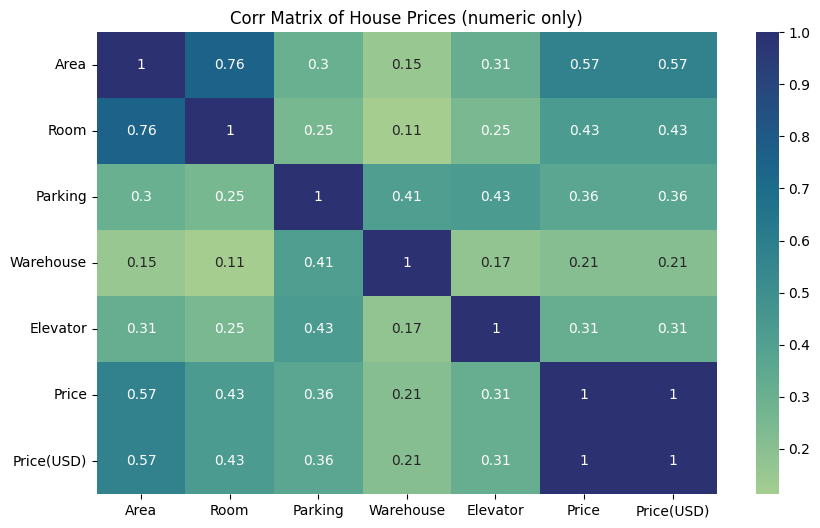

In [80]:
plt.figure(figsize=(10, 6))
sns.heatmap(data=df_corr, cmap='crest', annot=True)
plt.title('Corr Matrix of House Prices (numeric only)')
plt.show()

Index(['Area', 'Room', 'Price', 'Price(USD)'], dtype='object')


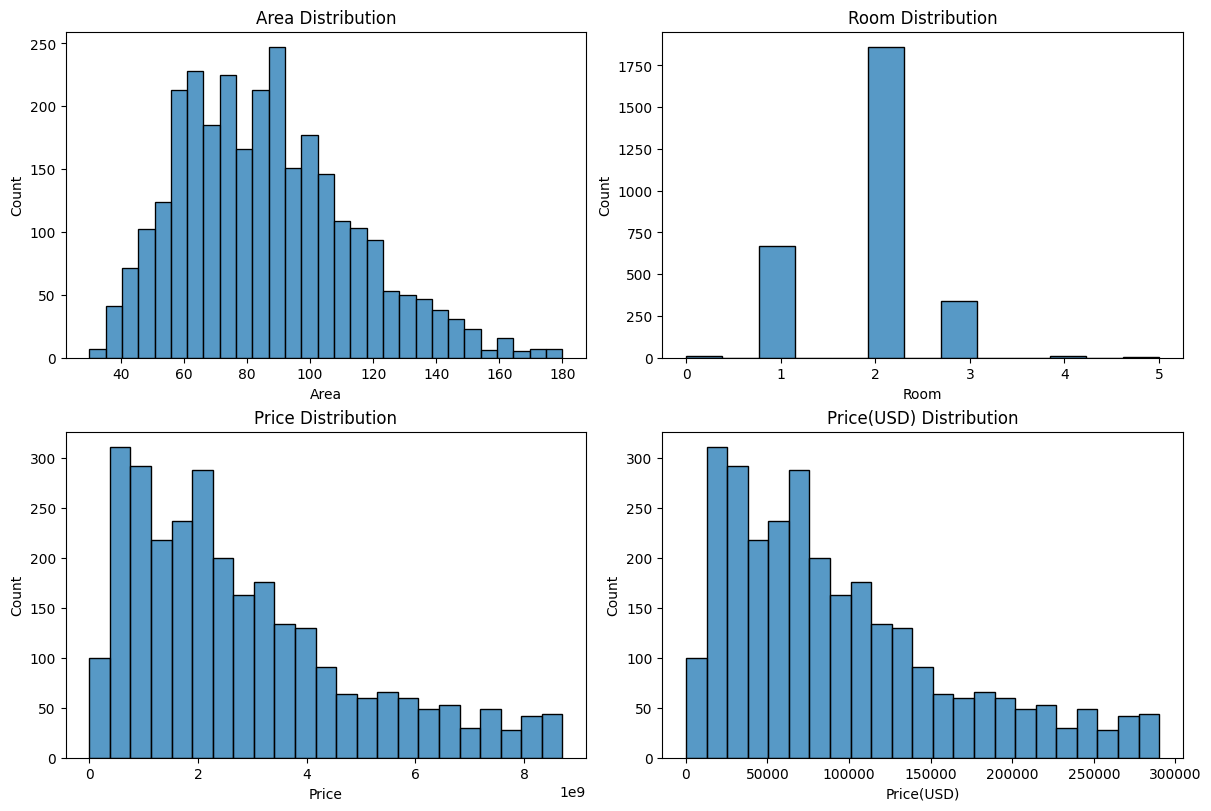

In [81]:
df_numeric_cols = df_numeric.columns
print(df_numeric_cols)

fig, axes = plt.subplots(2,2, constrained_layout=True, figsize=(12,8))
axes = axes.flatten()

for i, col in enumerate(df_numeric_cols):
    sns.histplot(data=df, x=col, ax=axes[i])
    axes[i].set_title(f'{col} Distribution')

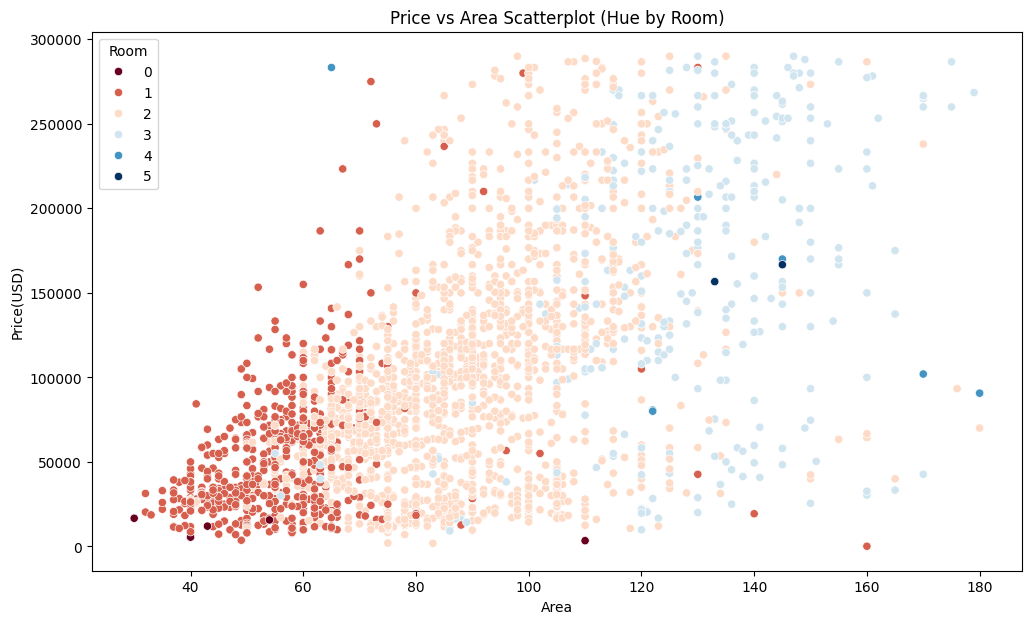

In [156]:
plt.figure(figsize=(12,7))
sns.scatterplot(df_numeric, x='Area', y='Price(USD)', hue='Room', palette='RdBu')
plt.title('Price vs Area Scatterplot (Hue by Room)')
plt.show()

# Transforming Data


## Changing Bool values to Integer

In [82]:
df['Parking'].value_counts()

Parking
True     2376
False     509
Name: count, dtype: int64

In [83]:
df_bools = df.select_dtypes('bool')
df_bool_cols = df_bools.columns
print(df_bool_cols)

for col in df_bool_cols:
    df[col] = df[col].astype(int)

df.info()

Index(['Parking', 'Warehouse', 'Elevator'], dtype='object')
<class 'pandas.core.frame.DataFrame'>
Index: 2885 entries, 0 to 3478
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Area        2885 non-null   int64 
 1   Room        2885 non-null   int64 
 2   Parking     2885 non-null   int64 
 3   Warehouse   2885 non-null   int64 
 4   Elevator    2885 non-null   int64 
 5   Address     2862 non-null   object
 6   Price       2885 non-null   int64 
 7   Price(USD)  2885 non-null   int64 
dtypes: int64(7), object(1)
memory usage: 202.9+ KB


## Adding features

## Splitting data for Training and Testing

In [84]:
x = df.drop(columns=['Address', 'Price', 'Price(USD)'])
y = df['Price(USD)']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
x_train

,Area,Room,Parking,Warehouse,Elevator
2260,120,3,1,1,1
1790,83,2,1,1,1
1191,79,2,1,1,1
3160,74,2,1,1,1
845,87,2,1,1,1
...,...,...,...,...,...
2076,76,2,1,1,1
1365,149,3,1,1,1
1410,120,3,1,1,1
1618,70,2,0,1,0


# Creating and Training Model

In [85]:
models_mae = []
models_mse = []
models_r2 = []

## Linear Regression

Mean Absolute Error: 2926017651.400502
Mean Squared Error: 39994.93774684521
R2 Score: 0.3645192615440802



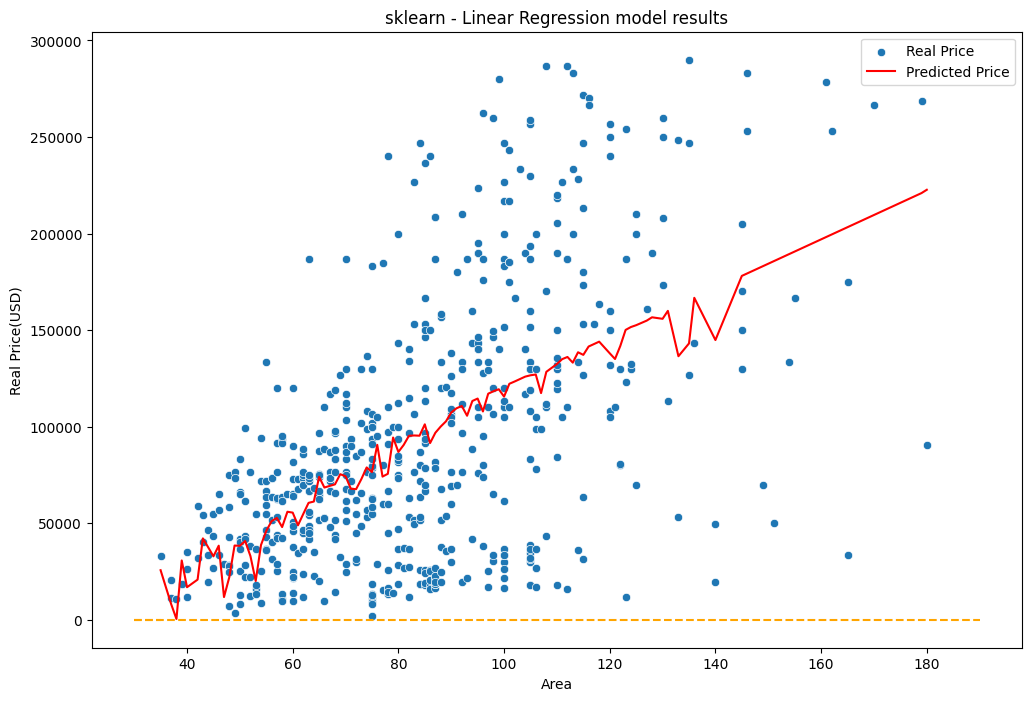

In [86]:
x = df.drop(columns=['Address', 'Price', 'Price(USD)'])
# x = df[['Area', 'Room']]
y = df['Price(USD)']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(x_train, y_train)

y_pred = model.predict(x_test)

x_test.insert(len(x_test.columns), 'Real Price(USD)', y_test)
x_test.insert(len(x_test.columns), 'Predicted Price(USD)', y_pred)
df_result = x_test.sort_values(by=['Area'], ascending=True)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

models_mae.append(mae)
models_mse.append(mse)
models_r2.append(r2)

print(f'Mean Absolute Error: {mse}')
print(f'Mean Squared Error: {mae}')
print(f'R2 Score: {r2}\n')

plt.figure(figsize=(12,8))
sns.scatterplot(data=df_result, x='Area', y='Real Price(USD)', label='Real Price')
sns.lineplot(data=df_result, x='Area', y='Predicted Price(USD)', color='red', label='Predicted Price', errorbar=None)
plt.hlines(y=(0,0), xmin=(30,30), xmax=(35,190), linestyles='--', color='orange')
plt.title('sklearn - Linear Regression model results')
plt.show()

## Decision Tree

Mean Absolute Error: 3221404490.433678
Mean Squared Error: 40976.50511200735
R2 Score: 0.300366317521642



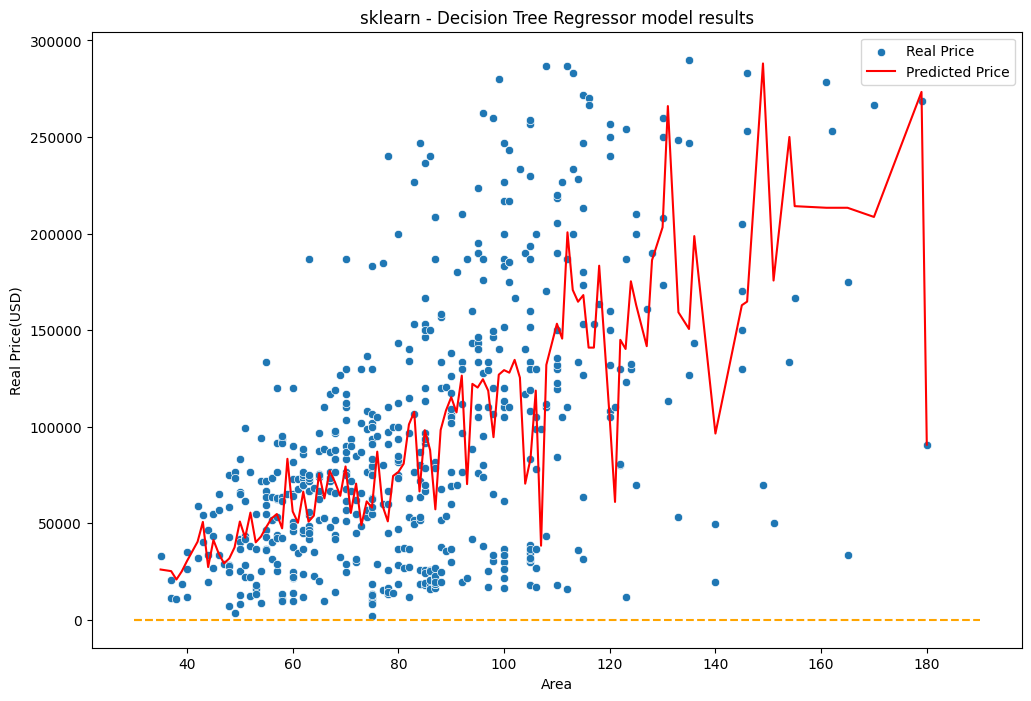

In [87]:
x = df.drop(columns=['Address', 'Price', 'Price(USD)'])
# x = df[['Area', 'Room']]
y = df['Price(USD)']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

model = DecisionTreeRegressor(splitter='best', criterion='squared_error')
model.fit(x_train, y_train)

y_pred = model.predict(x_test)

x_test.insert(len(x_test.columns), 'Real Price(USD)', y_test)
x_test.insert(len(x_test.columns), 'Predicted Price(USD)', y_pred)
df_result = x_test.sort_values(by=['Area'], ascending=True)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

models_mae.append(mae)
models_mse.append(mse)
models_r2.append(r2)

print(f'Mean Absolute Error: {mse}')
print(f'Mean Squared Error: {mae}')
print(f'R2 Score: {r2}\n')

plt.figure(figsize=(12,8))
sns.scatterplot(data=df_result, x='Area', y='Real Price(USD)', label='Real Price')
sns.lineplot(data=df_result, x='Area', y='Predicted Price(USD)', color='red', label='Predicted Price', errorbar=None)
plt.hlines(y=(0,0), xmin=(30,30), xmax=(35,190), linestyles='--', color='orange')
plt.title('sklearn - Decision Tree Regressor model results')
plt.show()

## Random Forest

Mean Absolute Error: 3152816637.77695
Mean Squared Error: 40757.06853130302
R2 Score: 0.31526242015948547



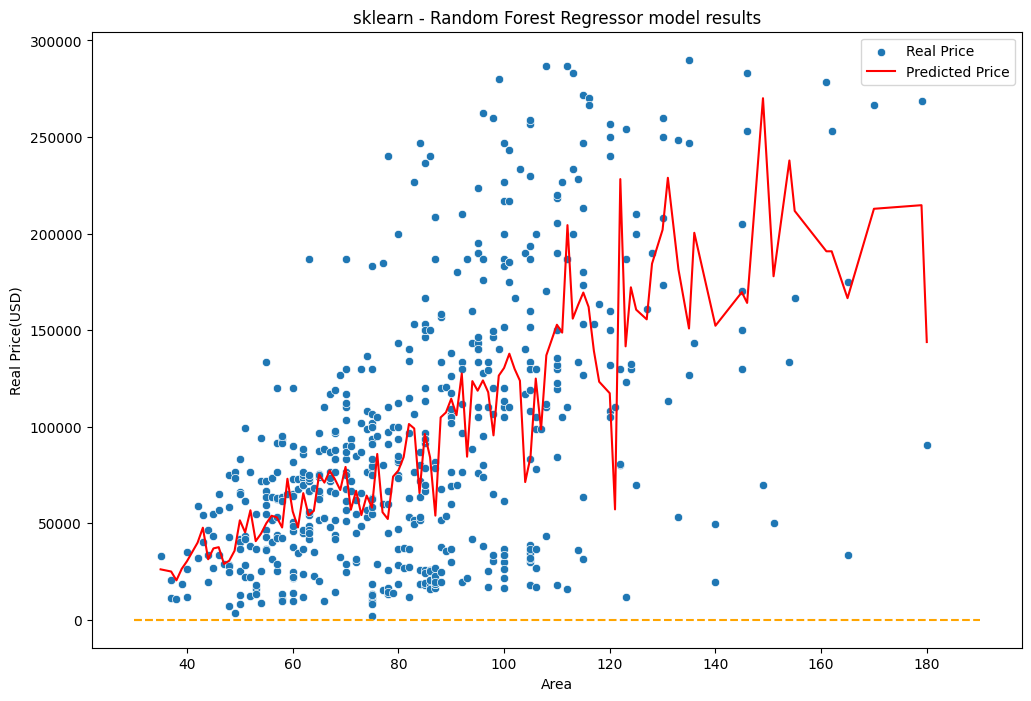

In [88]:
x = df.drop(columns=['Address', 'Price', 'Price(USD)'])
# x = df[['Area', 'Room']]
y = df['Price(USD)']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

model = RandomForestRegressor(criterion='squared_error')
model.fit(x_train, y_train)

y_pred = model.predict(x_test)

x_test.insert(len(x_test.columns), 'Real Price(USD)', y_test)
x_test.insert(len(x_test.columns), 'Predicted Price(USD)', y_pred)
df_result = x_test.sort_values(by=['Area'], ascending=True)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

models_mae.append(mae)
models_mse.append(mse)
models_r2.append(r2)

print(f'Mean Absolute Error: {mse}')
print(f'Mean Squared Error: {mae}')
print(f'R2 Score: {r2}\n')

plt.figure(figsize=(12,8))
sns.scatterplot(data=df_result, x='Area', y='Real Price(USD)', label='Real Price')
sns.lineplot(data=df_result, x='Area', y='Predicted Price(USD)', color='red', label='Predicted Price', errorbar=None)
plt.hlines(y=(0,0), xmin=(30,30), xmax=(35,190), linestyles='--', color='orange')
plt.title('sklearn - Random Forest Regressor model results')
plt.show()

## AdaBoost

Mean Absolute Error: 2852841934.541151
Mean Squared Error: 39265.50669617476
R2 Score: 0.3804117694257617



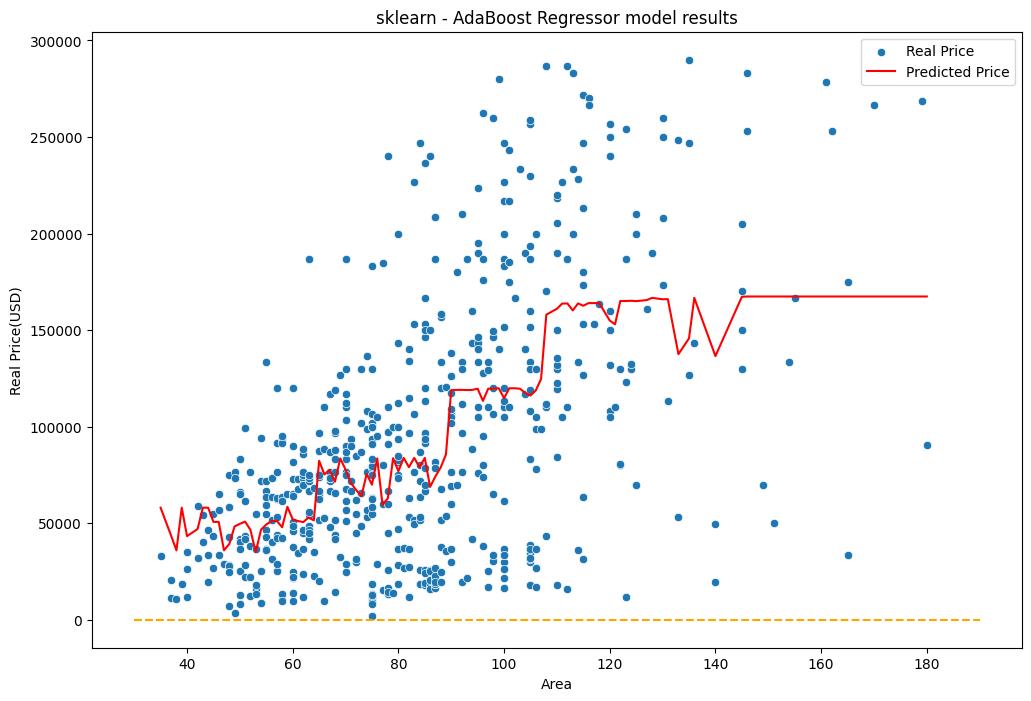

In [89]:
x = df.drop(columns=['Address', 'Price', 'Price(USD)'])
# x = df[['Area', 'Room']]
y = df['Price(USD)']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

model = AdaBoostRegressor(loss='square', learning_rate=0.01)
model.fit(x_train, y_train)

y_pred = model.predict(x_test)

x_test.insert(len(x_test.columns), 'Real Price(USD)', y_test)
x_test.insert(len(x_test.columns), 'Predicted Price(USD)', y_pred)
df_result = x_test.sort_values(by=['Area'], ascending=True)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

models_mae.append(mae)
models_mse.append(mse)
models_r2.append(r2)

print(f'Mean Absolute Error: {mse}')
print(f'Mean Squared Error: {mae}')
print(f'R2 Score: {r2}\n')

plt.figure(figsize=(12,8))
sns.scatterplot(data=df_result, x='Area', y='Real Price(USD)', label='Real Price')
sns.lineplot(data=df_result, x='Area', y='Predicted Price(USD)', color='red', label='Predicted Price', errorbar=None)
plt.hlines(y=(0,0), xmin=(30,30), xmax=(35,190), linestyles='--', color='orange')
plt.title('sklearn - AdaBoost Regressor model results')
plt.show()

## KNN

Mean Absolute Error: 3526813031.616776
Mean Squared Error: 42262.12131715771
R2 Score: 0.23403683205565862



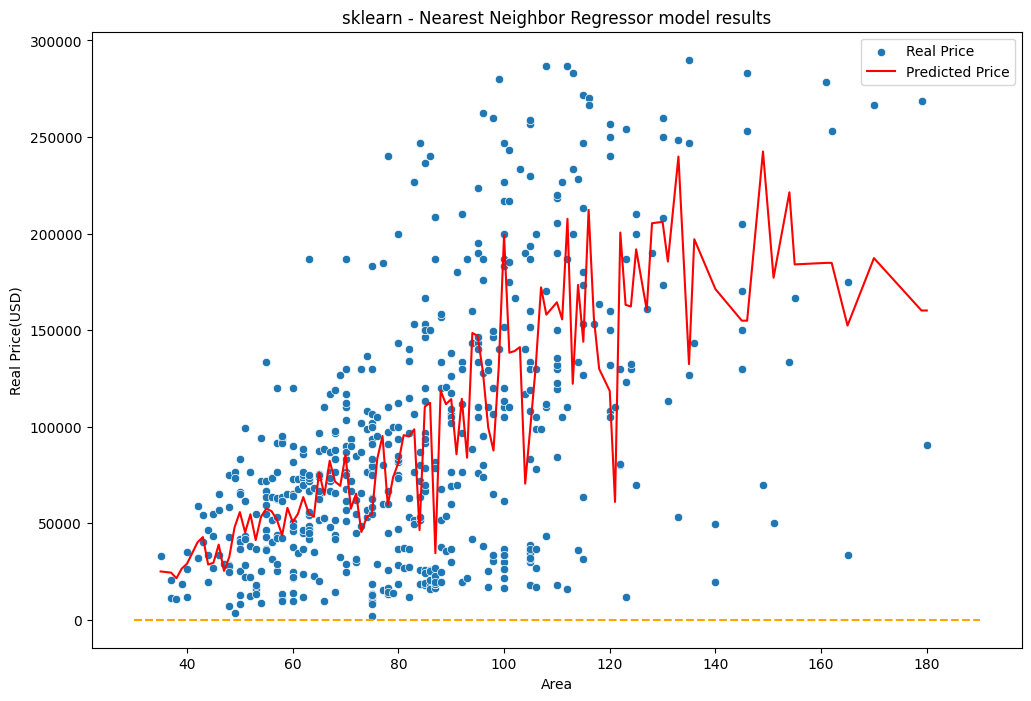

In [90]:
x = df.drop(columns=['Address', 'Price', 'Price(USD)'])
# x = df[['Area', 'Room']]
y = df['Price(USD)']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

model = KNeighborsRegressor(algorithm='auto', weights='uniform')
model.fit(x_train, y_train)

y_pred = model.predict(x_test)

x_test.insert(len(x_test.columns), 'Real Price(USD)', y_test)
x_test.insert(len(x_test.columns), 'Predicted Price(USD)', y_pred)
df_result = x_test.sort_values(by=['Area'], ascending=True)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

models_mae.append(mae)
models_mse.append(mse)
models_r2.append(r2)

print(f'Mean Absolute Error: {mse}')
print(f'Mean Squared Error: {mae}')
print(f'R2 Score: {r2}\n')

plt.figure(figsize=(12,8))
sns.scatterplot(data=df_result, x='Area', y='Real Price(USD)', label='Real Price')
sns.lineplot(data=df_result, x='Area', y='Predicted Price(USD)', color='red', label='Predicted Price', errorbar=None)
plt.hlines(y=(0,0), xmin=(30,30), xmax=(35,190), linestyles='--', color='orange')
plt.title('sklearn - Nearest Neighbor Regressor model results')
plt.show()

# Comparing Results

In [91]:
models = ['LinReg', 'DecTree', 'RanFor', 'AdaBoost', 'KNN']

df_model_results = pd.DataFrame([models, models_mae, models_mse, models_r2], index=['Model Name', 'Mean Absolute Error', 'Mean Squared Error', 'R-squared Score']).T
df_model_results

,Model Name,Mean Absolute Error,Mean Squared Error,R-squared Score
0,LinReg,39994.937747,2926017651.400502,0.364519
1,DecTree,40976.505112,3221404490.433678,0.300366
2,RanFor,40757.068531,3152816637.77695,0.315262
3,AdaBoost,39265.506696,2852841934.541151,0.380412
4,KNN,42262.121317,3526813031.616776,0.234037


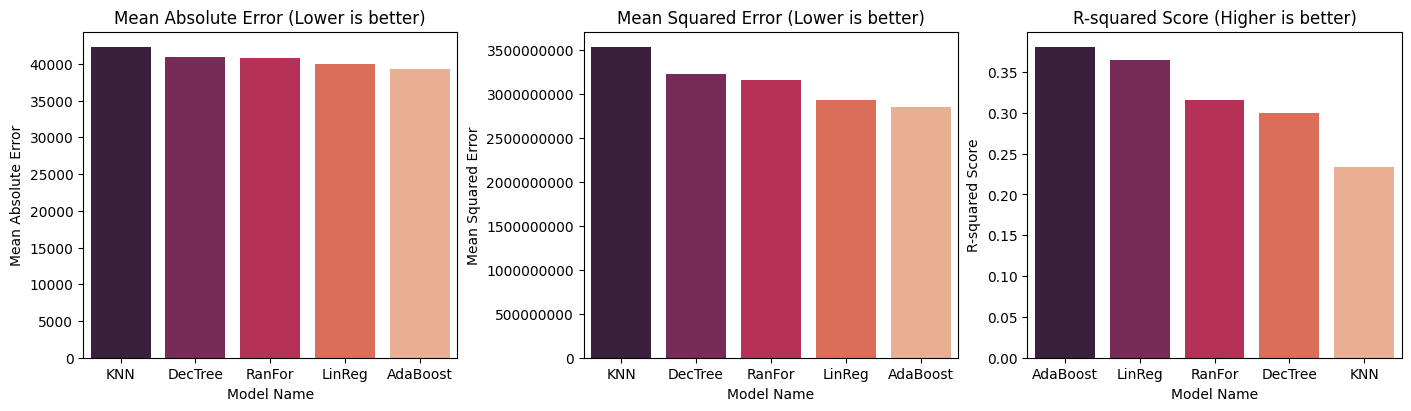

In [92]:
metric_cols = df_model_results.drop(columns='Model Name').columns

fig, axes = plt.subplots(1, 3, constrained_layout=True, figsize=(14,4))
axes = axes.flatten()

for i, col in enumerate(metric_cols):
    sorted_df = df_model_results.sort_values(by=col, ascending=False)
    
    sns.barplot(data=sorted_df, x='Model Name', y=col, ax=axes[i], hue='Model Name', palette='rocket')
    if col.lower() == 'r-squared score':
        axes[i].set_title(f'{col} (Higher is better)')
        # axes[i].set_ylim([0.5, 1])
    else:
        axes[i].set_title(f'{col} (Lower is better)')
        
    # axes[i].tick_params(axis='x', rotation=30)
    axes[i].ticklabel_format(style='plain', axis='y')

# Tuning Random Forest model

## Tuning model

In [160]:
def tune_random_forest_model(x, y):
    x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2)

    rf_regressor = RandomForestRegressor()

    param_grid = {
        'n_estimators': [100, 150, 200],
        'max_depth': [5, 10, 15, 20],
        'random_state': [44],
        'criterion': ['squared_error', 'absolute_error', 'friedman_mse', 'poisson'],
    }

    grid_search = GridSearchCV(estimator=rf_regressor, param_grid=param_grid,
                               scoring='neg_mean_absolute_error', cv=5, n_jobs=-1)

    grid_search.fit(x_train, y_train)
    
    best_params = grid_search.best_params_
    best_model = grid_search.best_estimator_

    y_pred = best_model.predict(x_test)

    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test ,y_pred)

    print(f'Best Parameters: {best_params}')
    print(f'Best Model: {best_model}')
    print(f'Mean Absolute Error on Test Set: {mae}')
    print(f'Mean Squared Error on Test Set: {mse}')
    print(f'R2 Score on Test Set: {r2}')
    return best_model, best_params, mae, mse ,r2

x = df.drop(columns=['Address', 'Price', 'Price(USD)'])
y = df['Price(USD)']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
x_train

best_model, best_params, mae, mse, r2 = tune_random_forest_model(x, y)

Best Parameters: {'criterion': 'absolute_error', 'max_depth': 10, 'n_estimators': 150, 'random_state': 44}
Best Model: RandomForestRegressor(criterion='absolute_error', max_depth=10,
                      n_estimators=150, random_state=44)
Mean Absolute Error on Test Set: 39471.15650491046
Mean Squared Error on Test Set: 3006561409.4920683
R2 Score on Test Set: 0.3826268727157436


## Creating model with best parameters

Mean Absolute Error: 3132979303.996039
Mean Squared Error: 40017.33108978588
R2 Score: 0.4029789754853197



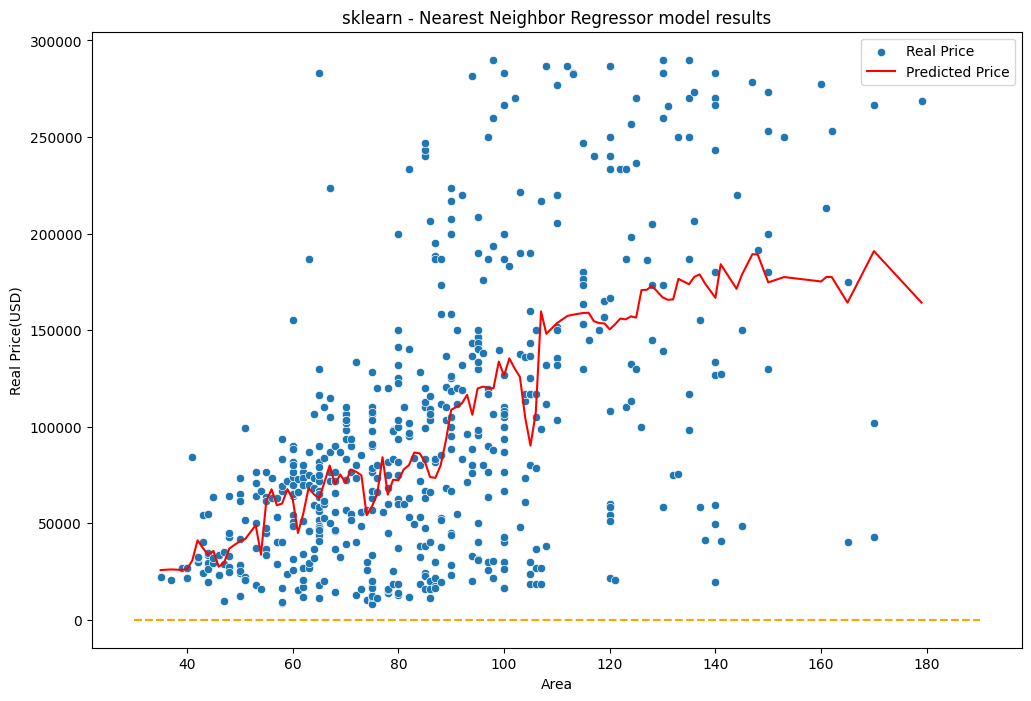

In [158]:
x = df.drop(columns=['Address', 'Price', 'Price(USD)'])
y = df['Price(USD)']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=44)

model = RandomForestRegressor(max_depth=5, n_estimators=200, random_state=44)
model.fit(x_train, y_train)

y_pred = model.predict(x_test)

x_test.insert(len(x_test.columns), 'Real Price(USD)', y_test)
x_test.insert(len(x_test.columns), 'Predicted Price(USD)', y_pred)
df_result = x_test.sort_values(by=['Area'], ascending=True)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

models_mae.append(mae)
models_mse.append(mse)
models_r2.append(r2)

print(f'Mean Absolute Error: {mse}')
print(f'Mean Squared Error: {mae}')
print(f'R2 Score: {r2}\n')

plt.figure(figsize=(12,8))
sns.scatterplot(data=df_result, x='Area', y='Real Price(USD)', label='Real Price')
sns.lineplot(data=df_result, x='Area', y='Predicted Price(USD)', color='red', label='Predicted Price', errorbar=None)
plt.hlines(y=(0,0), xmin=(30,30), xmax=(35,190), linestyles='--', color='orange')
plt.title('sklearn - Nearest Neighbor Regressor model results')
plt.show()